In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
import numpy as np

# Reading the arrays from the CSV file using NumPy
arrays = np.loadtxt('multiple_arrays.csv', delimiter=',')


In [3]:
# Reading the arrays from the CSV file using NumPy
arrays1 = np.loadtxt('multiple_arrays1.csv', delimiter=',')

In [4]:
# Reading the arrays from the CSV file using NumPy
arrays2 = np.loadtxt('multiple_arrays_qubit.csv', delimiter=',')

In [5]:
# Reading the arrays from the CSV file using NumPy
arrays3 = np.loadtxt('multiple_arrays_parallel.csv', delimiter=',')

In [6]:
# Reading the arrays from the CSV file using NumPy
arrays4 = np.loadtxt('multiple_arrays1_parallel.csv', delimiter=',')

In [7]:
# need to add this to normal qubit phase flip 
arrays5 = np.loadtxt('multiple_arrays1_parallel_time.csv', delimiter=',')

In [8]:
# need to add this to normal qubit phase flip 
arrays6 = np.loadtxt('multiple_arrays_hf.csv', delimiter=',')

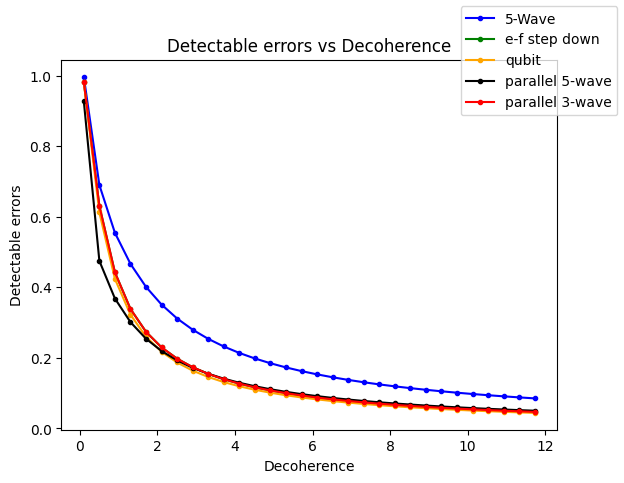

In [9]:
t1_list = np.linspace(.1, 120, 300)
fig, ax = plt.subplots()
ax.plot(t1_list[0:30], arrays[1][0:30], marker = ".", color="b", label = "5-Wave")
ax.plot(t1_list[0:30], arrays1[1][0:30], marker = ".", color="green", label = "e-f step down")
ax.plot(t1_list[0:30], arrays2[1][0:30], marker = ".", color="orange", label = "qubit")
ax.plot(t1_list[0:30], arrays3[1][0:30], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(t1_list[0:30], arrays4[1][0:30], marker = ".", color="red", label = "parallel 3-wave")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Detectable errors")
ax.set_title("Detectable errors vs Decoherence")
fig.legend()

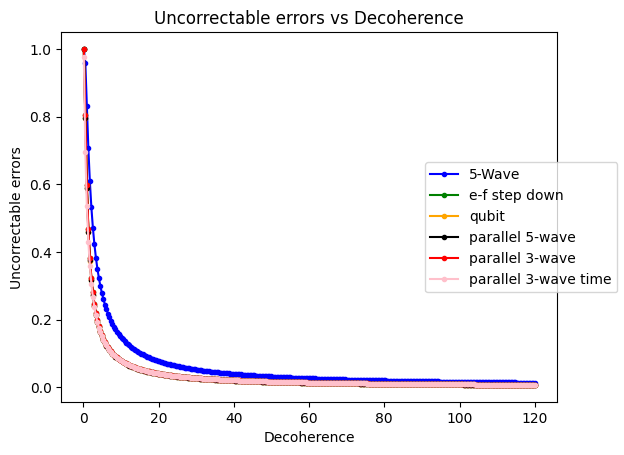

In [10]:
fig, ax = plt.subplots()
ax.plot(t1_list, arrays[2], marker = ".", color="b", label = "5-Wave")
ax.plot(t1_list, arrays1[2], marker = ".", color="green", label = "e-f step down")
ax.plot(t1_list, arrays2[2], marker = ".", color="orange", label = "qubit")
ax.plot(t1_list, arrays3[2], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(t1_list, arrays4[2], marker = ".", color="red", label = "parallel 3-wave")
ax.plot(t1_list, arrays5[2], marker = ".", color="pink", label = "parallel 3-wave time")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Uncorrectable errors")
ax.set_title("Uncorrectable errors vs Decoherence")
fig.legend(loc = "right")

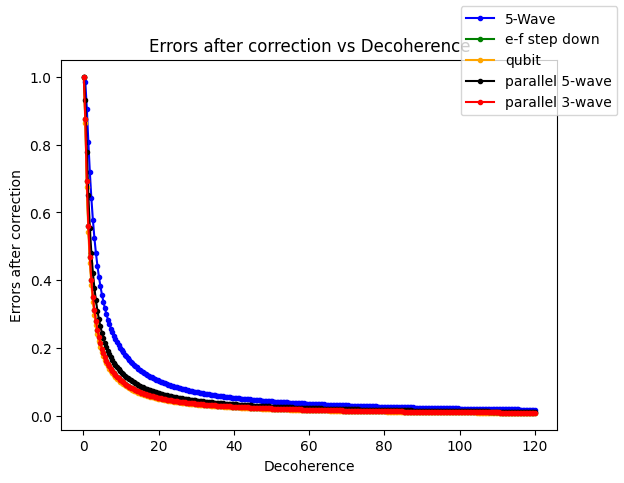

In [11]:
fig, ax = plt.subplots()
ax.plot(t1_list, arrays[0], marker = ".", color="b", label = "5-Wave")
ax.plot(t1_list, arrays1[0], marker = ".", color="green", label = "e-f step down")
ax.plot(t1_list, arrays2[0], marker = ".", color="orange", label = "qubit")
ax.plot(t1_list, arrays3[0], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(t1_list, arrays4[0], marker = ".", color="red", label = "parallel 3-wave")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Errors after correction")
ax.set_title("Errors after correction vs Decoherence")
fig.legend()

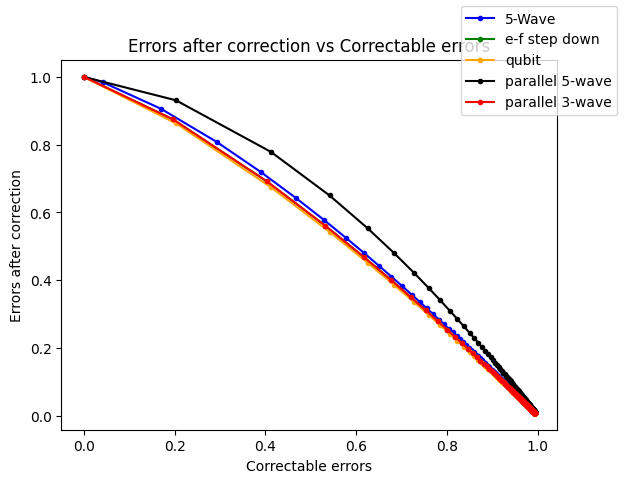

In [12]:
fig, ax = plt.subplots()
ax.plot(arrays[3], arrays[0], marker = ".", color="b", label = "5-Wave")
ax.plot(arrays1[3], arrays1[0], marker = ".", color="green", label = "e-f step down")
ax.plot(arrays2[3], arrays2[0], marker = ".", color="orange", label = "qubit")
ax.plot(arrays3[3], arrays3[0], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(arrays4[3], arrays4[0], marker = ".", color="red", label = "parallel 3-wave")
ax.set_xlabel("Correctable errors")
ax.set_ylabel("Errors after correction")
ax.set_title("Errors after correction vs Correctable errors")
fig.legend()

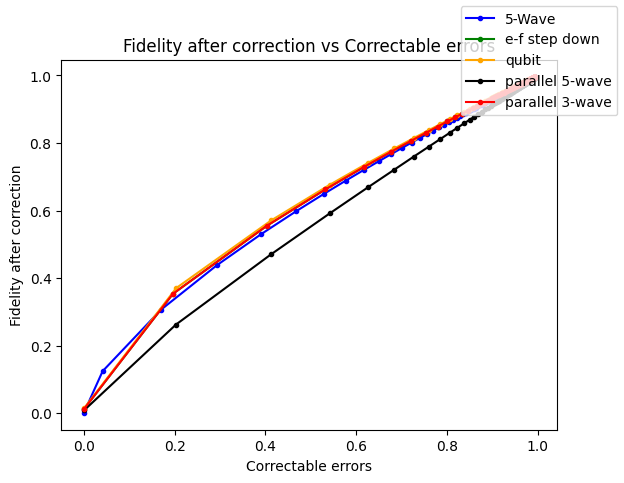

In [13]:
# for how good they all correct, have fidelity after correction as a function of correctable errors 
fig, ax = plt.subplots()
ax.plot(arrays[3], arrays[4], marker = ".", color="b", label = "5-Wave")
ax.plot(arrays1[3], arrays1[4], marker = ".", color="green", label = "e-f step down")
ax.plot(arrays2[3], arrays2[4], marker = ".", color="orange", label = "qubit")
ax.plot(arrays3[3], arrays3[4], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(arrays4[3], arrays4[4], marker = ".", color="red", label = "parallel 3-wave")
ax.set_xlabel("Correctable errors")
ax.set_ylabel("Fidelity after correction")
ax.set_title("Fidelity after correction vs Correctable errors")
fig.legend()

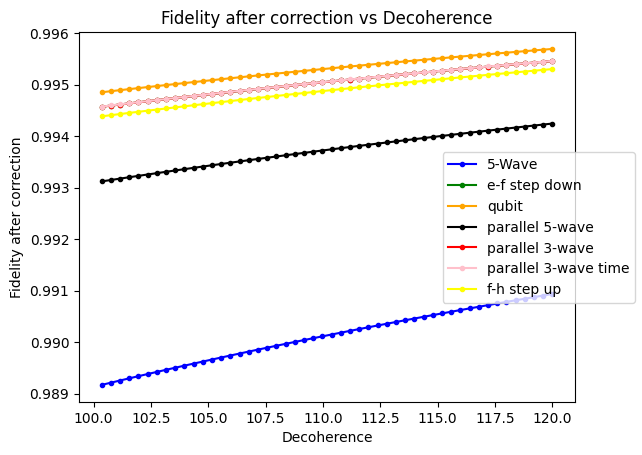

In [14]:
# for how good they all correct, have fidelity after correction as a function of correctable errors 
fig, ax = plt.subplots()
ax.plot(t1_list[250:300], arrays[4][250:300], marker = ".", color="b", label = "5-Wave")
ax.plot(t1_list[250:300], arrays1[4][250:300], marker = ".", color="green", label = "e-f step down")
ax.plot(t1_list[250:300], arrays2[4][250:300], marker = ".", color="orange", label = "qubit")
ax.plot(t1_list[250:300], arrays3[4][250:300], marker = ".", color="black", label = "parallel 5-wave")
ax.plot(t1_list[250:300], arrays4[4][250:300], marker = ".", color="red", label = "parallel 3-wave")
ax.plot(t1_list[250:300], arrays5[4][250:300], marker = ".", color="pink", label = "parallel 3-wave time")
ax.plot(t1_list[250:300], arrays6[4][250:300], marker = ".", color="yellow", label = "f-h step up")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Fidelity after correction")
ax.set_title("Fidelity after correction vs Decoherence")
fig.legend(loc="center right")
# ax.set_yscale("log")

In [15]:
# # for how good they all correct, have fidelity after correction as a function of correctable errors 
# fig, ax = plt.subplots()
# ax.plot(t1_list[0:30], arrays[4][0:30], marker = ".", color="b", label = "5-Wave")
# ax.plot(t1_list[0:30], arrays1[4][0:30], marker = ".", color="green", label = "e-f step down")
# ax.plot(arrays2[3], arrays2[4], marker = ".", color="orange", label = "qubit")
# ax.plot(t1_list[0:30], arrays3[4][0:30], marker = ".", color="black", label = "parallel 5-wave")
# ax.plot(t1_list[25:30], arrays4[4][25:30], marker = ".", color="red", label = "parallel 3-wave")
# ax.plot(t1_list[25:30], arrays5[4][25:30], marker = ".", color="pink", label = "parallel 3-wave time")
# ax.set_xlabel("Decoherence")
# ax.set_ylabel("Fidelity after correction")
# ax.set_title("Fidelity after correction vs Decoherence")
# fig.legend()